In [1]:
!pip install optuna mlflow shap --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 14.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import shap
import optuna
import mlflow
import mlflow.sklearn

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


In [3]:
# Load dataset directly from WA.gov API
df = pd.read_csv('https://data.wa.gov/api/views/f6w7-q2d2/rows.csv?accessType=DOWNLOAD')
print(f"✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

✅ Dataset loaded: 279,780 rows × 16 columns


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JN1AZ0CP5C,Stevens,Colville,WA,99114.0,2012,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,7.0,153331706,POINT (-117.90454 48.54657),AVISTA CORP,5.306595e+10
1,JTMABABA7P,Yakima,Yakima,WA,98903.0,2023,SUBARU,SOLTERRA,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,15.0,253586308,POINT (-120.71847 46.55029),PACIFICORP,5.307700e+10
2,1N4AZ1CP1J,King,Seattle,WA,98122.0,2018,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,151.0,37.0,333135022,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5UX43EU09S,Kitsap,Poulsbo,WA,98370.0,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,23.0,267525737,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303594e+10
4,3C3CFFGE5F,Thurston,Yelm,WA,98597.0,2015,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87.0,2.0,474468501,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10


In [4]:
# ── Overview ──────────────────────────────────────────────
print("=" * 55)
print(f"  Shape         : {df.shape}")
print(f"  Numeric cols  : {df.select_dtypes(include='number').shape[1]}")
print(f"  Categorical   : {df.select_dtypes(include='object').shape[1]}")
print(f"  Duplicate rows: {df.duplicated().sum():,}")
print(f"  Total nulls   : {df.isnull().sum().sum():,}")
print("=" * 55)

# Target distribution
print(f"\nElectric Range stats:")
print(df['Electric Range'].describe().round(2))
print(f"\nRows where Electric Range == 0: {(df['Electric Range'] == 0).sum():,}")

  Shape         : (279780, 16)
  Numeric cols  : 6
  Categorical   : 10
  Duplicate rows: 0
  Total nulls   : 940

Electric Range stats:
count    279769.00
mean         39.17
std          78.23
min           0.00
25%           0.00
50%           0.00
75%          32.00
max         337.00
Name: Electric Range, dtype: float64

Rows where Electric Range == 0: 177,937


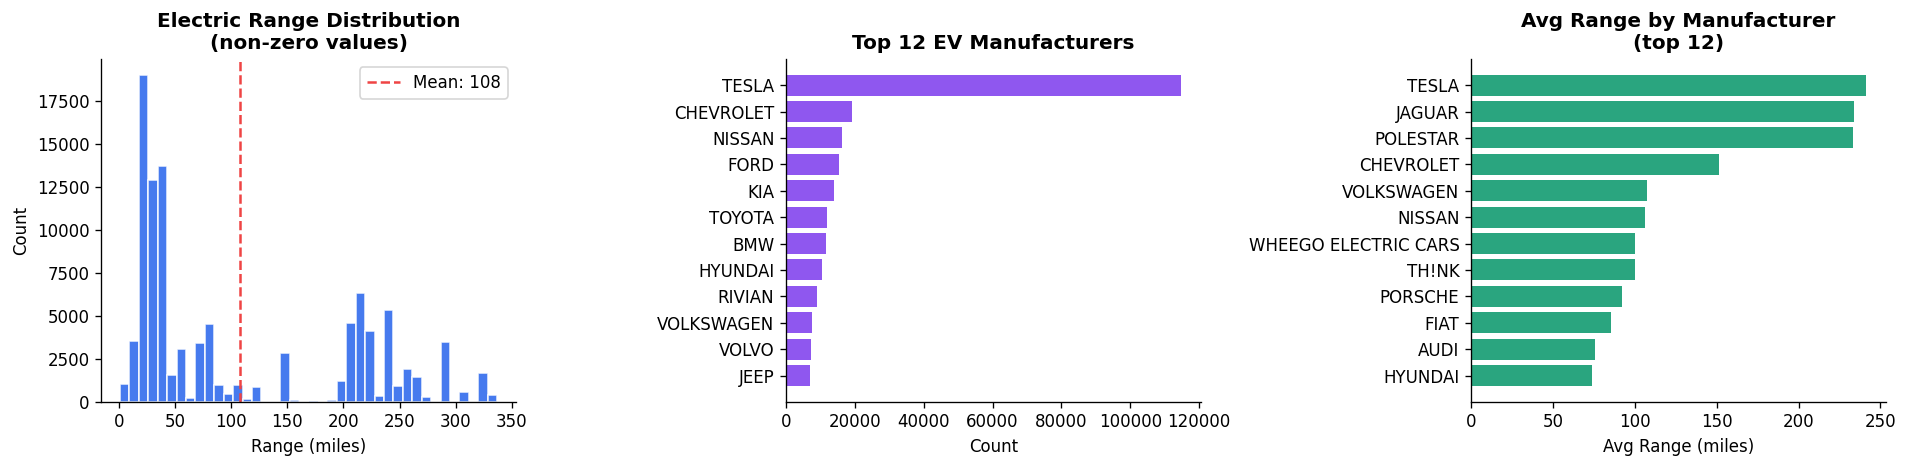

Skewness of target: 0.724


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution of target (after filtering zeros)
valid = df[df['Electric Range'] > 0]['Electric Range']
axes[0].hist(valid, bins=40, color='#2563eb', alpha=0.85, edgecolor='white')
axes[0].set_title('Electric Range Distribution\n(non-zero values)', fontweight='bold')
axes[0].set_xlabel('Range (miles)')
axes[0].set_ylabel('Count')
axes[0].axvline(valid.mean(), color='#ef4444', linestyle='--', label=f'Mean: {valid.mean():.0f}')
axes[0].legend()

# Top 12 EV makes by count
top_makes = df['Make'].value_counts().head(12)
axes[1].barh(top_makes.index[::-1], top_makes.values[::-1], color='#7c3aed', alpha=0.85)
axes[1].set_title('Top 12 EV Manufacturers', fontweight='bold')
axes[1].set_xlabel('Count')

# Average range by top makes
avg_range = (df[df['Electric Range'] > 0]
             .groupby('Make')['Electric Range']
             .mean()
             .sort_values(ascending=False)
             .head(12))
axes[2].barh(avg_range.index[::-1], avg_range.values[::-1], color='#059669', alpha=0.85)
axes[2].set_title('Avg Range by Manufacturer\n(top 12)', fontweight='bold')
axes[2].set_xlabel('Avg Range (miles)')

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()
print("Skewness of target:", round(valid.skew(), 3))

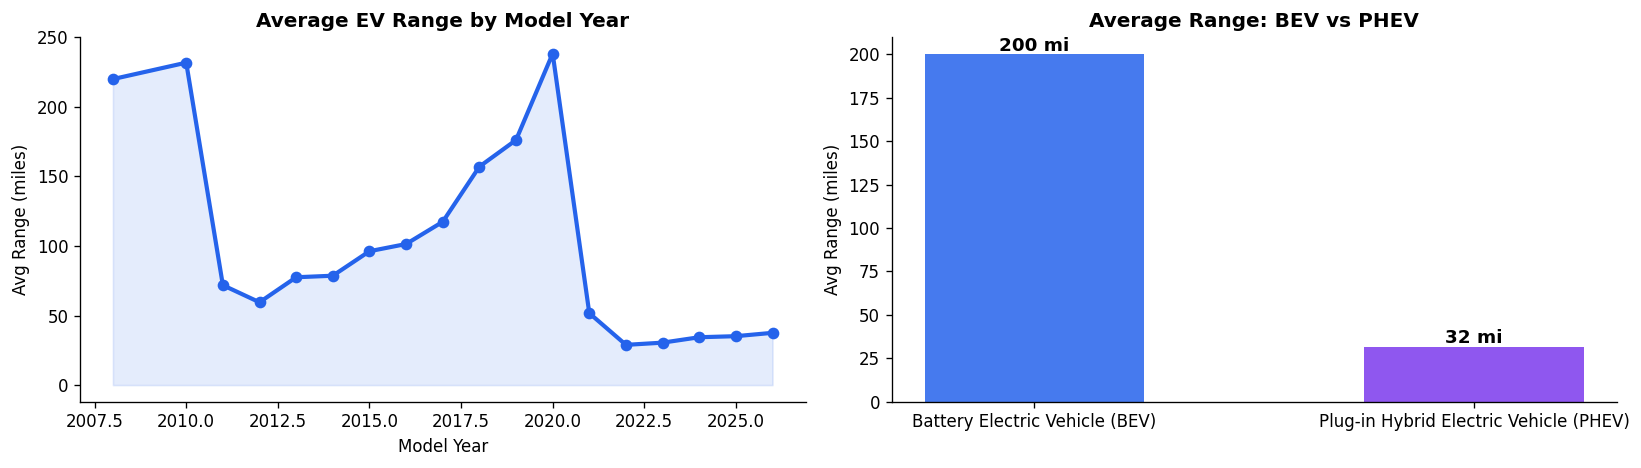

In [6]:
# Model year vs electric range trend
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

valid_df = df[df['Electric Range'] > 0].copy()

year_range = (valid_df.groupby('Model Year')['Electric Range']
              .agg(['mean','count'])
              .reset_index())
year_range = year_range[year_range['count'] > 10]

axes[0].plot(year_range['Model Year'], year_range['mean'],
             marker='o', color='#2563eb', linewidth=2.5)
axes[0].fill_between(year_range['Model Year'], year_range['mean'],
                     alpha=0.12, color='#2563eb')
axes[0].set_title('Average EV Range by Model Year', fontweight='bold')
axes[0].set_xlabel('Model Year')
axes[0].set_ylabel('Avg Range (miles)')

# BEV vs PHEV range comparison
ev_type = valid_df.groupby('Electric Vehicle Type')['Electric Range'].mean()
bars = axes[1].bar(ev_type.index, ev_type.values,
                   color=['#2563eb', '#7c3aed'], alpha=0.85, width=0.5)
axes[1].set_title('Average Range: BEV vs PHEV', fontweight='bold')
axes[1].set_ylabel('Avg Range (miles)')
axes[1].set_xlabel('')
for bar, val in zip(bars, ev_type.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val:.0f} mi', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('eda_trends.png', bbox_inches='tight')
plt.show()

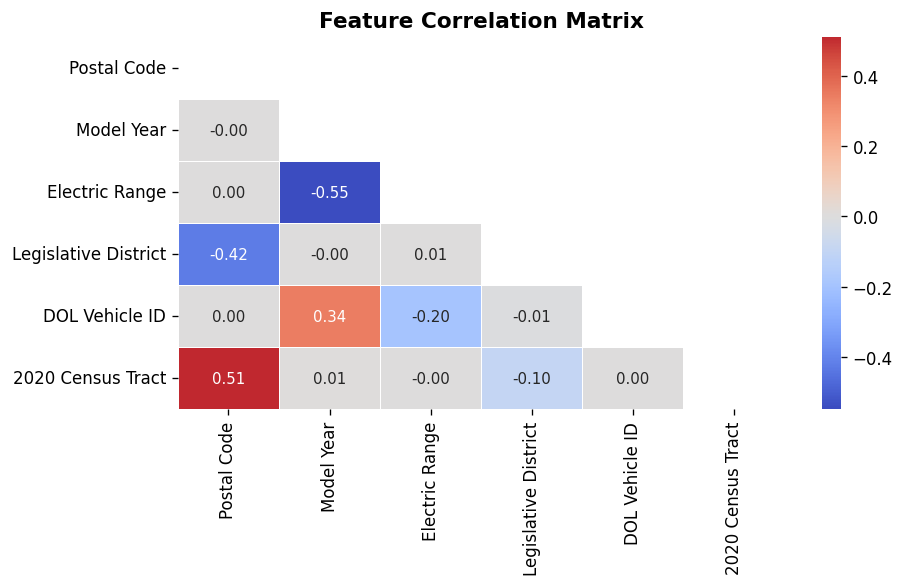

In [7]:
# Correlation heatmap for numeric features
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()

plt.figure(figsize=(8, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [8]:
# ── Step 1: Filter zero-range rows ────────────────────────
# Rows with Electric Range == 0 are PHEVs with no reported range
# or missing data encoded as 0 — they corrupt the model
print(f"Rows before filtering : {len(df):,}")
df_clean = df[df['Electric Range'] > 0].copy()
print(f"Rows after filtering  : {len(df_clean):,}")
print(f"Removed               : {len(df) - len(df_clean):,} zero-range rows")

# ── Step 2: Drop administrative / non-predictive columns ──
# These are DMV registration fields — they carry no signal
# about the physical range capability of a vehicle
drop_cols = [
    'VIN (1-10)',           # partial VIN — registry artifact
    'DOL Vehicle ID',       # internal DMV ID
    'Vehicle Location',     # GPS coords of registration address
    'County',               # where owner lives, not vehicle spec
    'City',
    'State',
    'Postal Code',
    'Legislative District', # political district of owner
    '2020 Census Tract',    # census admin field
]
df_clean = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns])
print(f"\nColumns after dropping admin fields: {df_clean.shape[1]}")

# ── Step 3: Remove duplicates ──────────────────────────────
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Duplicates removed    : {before - len(df_clean):,}")

# ── Step 4: Fill remaining nulls ──────────────────────────
num_cols = df_clean.select_dtypes(include=np.number).columns
cat_cols = df_clean.select_dtypes(exclude=np.number).columns

df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())
df_clean[cat_cols] = df_clean[cat_cols].fillna("Unknown")

print(f"\nRemaining nulls: {df_clean.isnull().sum().sum()}")
print(f"\n✅ Cleaned dataset shape: {df_clean.shape}")

Rows before filtering : 279,780
Rows after filtering  : 101,832
Removed               : 177,948 zero-range rows

Columns after dropping admin fields: 7
Duplicates removed    : 93,780

Remaining nulls: 0

✅ Cleaned dataset shape: (8052, 7)


In [9]:
# ── Feature Engineering ───────────────────────────────────
# Extract vehicle age (can signal battery tech generation)
current_year = 2025
df_clean['Vehicle Age'] = current_year - df_clean['Model Year']

# Flag if vehicle is BEV (pure electric) or PHEV
df_clean['Is_BEV'] = (
    df_clean['Electric Vehicle Type']
    .str.contains('Battery Electric', case=False, na=False)
    .astype(int)
)

# CAFV eligibility as binary flag
df_clean['CAFV_Eligible'] = (
    df_clean['Clean Alternative Fuel Vehicle (CAFV) Eligibility']
    .str.contains('Clean Alternative', case=False, na=False)
    .astype(int)
)

print("✅ New features added: Vehicle Age, Is_BEV, CAFV_Eligible")
print(df_clean[['Model Year','Vehicle Age','Is_BEV','CAFV_Eligible','Electric Range']].head())

✅ New features added: Vehicle Age, Is_BEV, CAFV_Eligible
   Model Year  Vehicle Age  Is_BEV  CAFV_Eligible  Electric Range
0        2012           13       1              1            73.0
2        2018            7       1              1           151.0
3        2025            0       0              1            40.0
4        2015           10       1              1            87.0
5        2015           10       1              1            84.0


In [10]:
# Define features and target
TARGET = 'Electric Range'

# Keep only the most signal-rich columns
keep_cols = [
    'Model Year', 'Make', 'Model',
    'Electric Vehicle Type',
    'Clean Alternative Fuel Vehicle (CAFV) Eligibility',
    'Base MSRP',
    'Vehicle Age', 'Is_BEV', 'CAFV_Eligible'
]
# Only keep columns that exist
keep_cols = [c for c in keep_cols if c in df_clean.columns]

X = df_clean[keep_cols]
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Clip outliers on TRAIN only (never touch test set) ────
Q1, Q3 = y_train.quantile(0.25), y_train.quantile(0.75)
IQR = Q3 - Q1
y_train = np.clip(y_train, Q1 - 1.5*IQR, Q3 + 1.5*IQR)

print(f"Training set   : {X_train.shape[0]:,} rows")
print(f"Test set       : {X_test.shape[0]:,} rows")
print(f"Features       : {X_train.shape[1]}")
print(f"\nFeatures used  : {list(X_train.columns)}")

Training set   : 6,441 rows
Test set       : 1,611 rows
Features       : 8

Features used  : ['Model Year', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Vehicle Age', 'Is_BEV', 'CAFV_Eligible']


In [11]:
num_features = X_train.select_dtypes(include=np.number).columns.tolist()
cat_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features)
])

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", rf)
])

print(f"✅ Pipeline ready")
print(f"   Numeric features    : {num_features}")
print(f"   Categorical features: {cat_features}")


✅ Pipeline ready
   Numeric features    : ['Model Year', 'Vehicle Age', 'Is_BEV', 'CAFV_Eligible']
   Categorical features: ['Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility']


In [12]:
def objective(trial):
    params = {
        "model__n_estimators"     : trial.suggest_int("n_estimators", 100, 500),
        "model__max_depth"        : trial.suggest_int("max_depth", 5, 40),
        "model__min_samples_split": trial.suggest_int("min_samples_split", 2, 15),
        "model__min_samples_leaf" : trial.suggest_int("min_samples_leaf", 1, 10),
        "model__max_features"     : trial.suggest_categorical("max_features", ["sqrt", "log2"]),
    }
    pipeline.set_params(**params)
    score = cross_val_score(
        pipeline, X_train, y_train,
        cv=5, scoring="r2", n_jobs=-1
    ).mean()
    return score

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=40, show_progress_bar=True)

print(f"\n✅ Optimization complete")
print(f"   Best CV R²  : {study.best_value:.4f}")
print(f"   Best params : {study.best_params}")

  0%|          | 0/40 [00:00<?, ?it/s]


✅ Optimization complete
   Best CV R²  : 0.9993
   Best params : {'n_estimators': 437, 'max_depth': 33, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2'}


In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import shap

# Apply best params
pipeline.set_params(**{f"model__{k}": v for k, v in study.best_params.items()})

mlflow.set_experiment("EV_Range_Prediction")

with mlflow.start_run(run_name="RandomForest_Optuna_v1"):

    pipeline.fit(X_train, y_train)

    train_pred = pipeline.predict(X_train)
    test_pred  = pipeline.predict(X_test)

    r2_train = r2_score(y_train, train_pred)
    r2_test  = r2_score(y_test,  test_pred)
    mae      = mean_absolute_error(y_test, test_pred)
    rmse     = np.sqrt(mean_squared_error(y_test, test_pred))
    overfit  = r2_train - r2_test

    # Log everything
    mlflow.log_params(study.best_params)
    mlflow.log_param("n_features", X_train.shape[1])
    mlflow.log_param("train_size", len(X_train))
    mlflow.log_metric("r2_train",  round(r2_train, 4))
    mlflow.log_metric("r2_test",   round(r2_test,  4))
    mlflow.log_metric("mae",       round(mae,       4))
    mlflow.log_metric("rmse",      round(rmse,      4))
    mlflow.log_metric("overfit_gap", round(overfit, 4))
    mlflow.sklearn.log_model(pipeline, "ev_range_model",
                             registered_model_name="EV_Range_Predictor")
    # Log existing EDA plots
    mlflow.log_artifact('eda_overview.png', artifact_path="plots")
    mlflow.log_artifact('eda_trends.png', artifact_path="plots")
    mlflow.log_artifact('correlation_heatmap.png', artifact_path="plots")

    # --- Generate and Log Model Evaluation Plot ---
    fig_eval, axes_eval = plt.subplots(1, 3, figsize=(17, 5))
    axes_eval[0].scatter(y_test, test_pred, alpha=0.35, color='#2563eb', s=12)
    lims = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
    axes_eval[0].plot(lims, lims, 'r--', linewidth=1.8, label='Perfect prediction')
    axes_eval[0].set_xlabel('Actual Range (miles)')
    axes_eval[0].set_ylabel('Predicted Range (miles)')
    axes_eval[0].set_title(f'Actual vs Predicted\nR² = {r2_test:.4f}', fontweight='bold')
    axes_eval[0].legend()
    residuals = y_test - test_pred
    axes_eval[1].hist(residuals, bins=40, color='#7c3aed', alpha=0.8, edgecolor='white')
    axes_eval[1].axvline(0, color='#ef4444', linestyle='--', linewidth=1.8)
    axes_eval[1].set_xlabel('Residual (miles)')
    axes_eval[1].set_ylabel('Count')
    axes_eval[1].set_title(f'Residuals Distribution\nMean={residuals.mean():.2f}, Std={residuals.std():.2f}',
                      fontweight='bold')
    axes_eval[2].scatter(test_pred, residuals, alpha=0.3, color='#059669', s=12)
    axes_eval[2].axhline(0, color='#ef4444', linestyle='--', linewidth=1.8)
    axes_eval[2].set_xlabel('Predicted Range (miles)')
    axes_eval[2].set_ylabel('Residual')
    axes_eval[2].set_title('Residuals vs Predicted\n(Homoscedasticity Check)', fontweight='bold')
    plt.suptitle('Model Evaluation Dashboard', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('model_evaluation.png', bbox_inches='tight')
    plt.close(fig_eval)
    mlflow.log_artifact('model_evaluation.png', artifact_path="plots")

    # --- Generate and Log Feature Importance Plot ---
    feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()
    importances   = pipeline.named_steps["model"].feature_importances_
    importance_df = (pd.DataFrame({"Feature": feature_names, "Importance": importances})
                     .sort_values("Importance", ascending=False)
                     .head(20)
                     .reset_index(drop=True))
    fig_imp = plt.figure(figsize=(9, 6))
    colors = ['#2563eb' if i < 5 else '#93c5fd' for i in range(len(importance_df))]
    plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1],
             color=colors[::-1], alpha=0.9)
    plt.xlabel('Importance Score')
    plt.title('Top 20 Feature Importances (Random Forest)', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig('feature_importance.png', bbox_inches='tight')
    plt.close(fig_imp)
    mlflow.log_artifact('feature_importance.png', artifact_path="plots")

    # --- Generate and Log SHAP Summary Plot ---
    X_test_transformed = pipeline.named_steps["preprocess"].transform(X_test)
    explainer   = shap.TreeExplainer(pipeline.named_steps["model"])
    shap_values = explainer.shap_values(X_test_transformed[:500])
    fig_shap = plt.figure()
    shap.summary_plot(
        shap_values,
        X_test_transformed[:500],
        feature_names=feature_names,
        show=False,
        max_display=15,
        plot_size=(10, 6)
    )
    plt.title("SHAP Summary — Feature Impact on Predictions", fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_summary.png', bbox_inches='tight')
    plt.close(fig_shap)
    mlflow.log_artifact('shap_summary.png', artifact_path="plots")


print("=" * 45)
print(f"  R² Train   : {r2_train:.4f}")
print(f"  R² Test    : {r2_test:.4f}")
print(f"  Overfit gap: {overfit:.4f}  {'✅ Good' if overfit < 0.05 else '⚠️  Check overfit'}")
print(f"  MAE        : {mae:.2f} miles")
print(f"  RMSE       : {rmse:.2f} miles")
print("=" * 45)
print("✅ MLflow run logged.")

2026/03/19 14:55:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/19 14:55:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'EV_Range_Predictor' already exists. Creating a new version of this model...
Created version '3' of model 'EV_Range_Predictor'.


  R² Train   : 0.9995
  R² Test    : 0.8363
  Overfit gap: 0.1632  ⚠️  Check overfit
  MAE        : 13.43 miles
  RMSE       : 34.67 miles
✅ MLflow run logged.


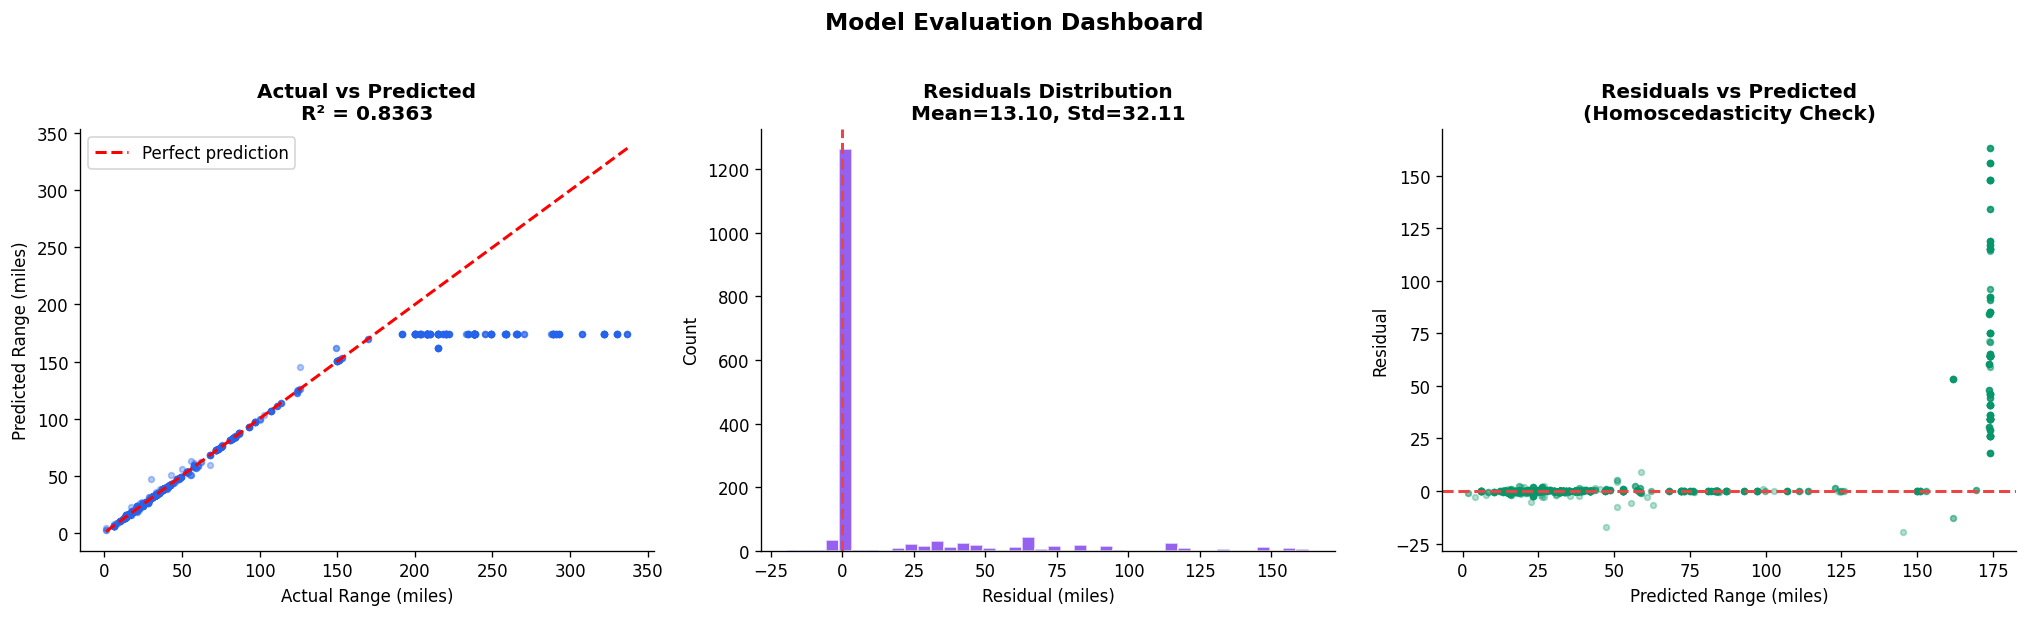

✅ Evaluation complete — MAE: 13.43 miles | RMSE: 34.67 miles


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_test, test_pred, alpha=0.35, color='#2563eb', s=12)
lims = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.8, label='Perfect prediction')
axes[0].set_xlabel('Actual Range (miles)')
axes[0].set_ylabel('Predicted Range (miles)')
axes[0].set_title(f'Actual vs Predicted\nR² = {r2_test:.4f}', fontweight='bold')
axes[0].legend()

# 2. Residuals distribution
residuals = y_test - test_pred
axes[1].hist(residuals, bins=40, color='#7c3aed', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='#ef4444', linestyle='--', linewidth=1.8)
axes[1].set_xlabel('Residual (miles)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residuals Distribution\nMean={residuals.mean():.2f}, Std={residuals.std():.2f}',
                  fontweight='bold')

# 3. Residuals vs Predicted (homoscedasticity check)
axes[2].scatter(test_pred, residuals, alpha=0.3, color='#059669', s=12)
axes[2].axhline(0, color='#ef4444', linestyle='--', linewidth=1.8)
axes[2].set_xlabel('Predicted Range (miles)')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs Predicted\n(Homoscedasticity Check)', fontweight='bold')

plt.suptitle('Model Evaluation Dashboard', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_evaluation.png', bbox_inches='tight')
plt.show()

print(f"✅ Evaluation complete — MAE: {mae:.2f} miles | RMSE: {rmse:.2f} miles")

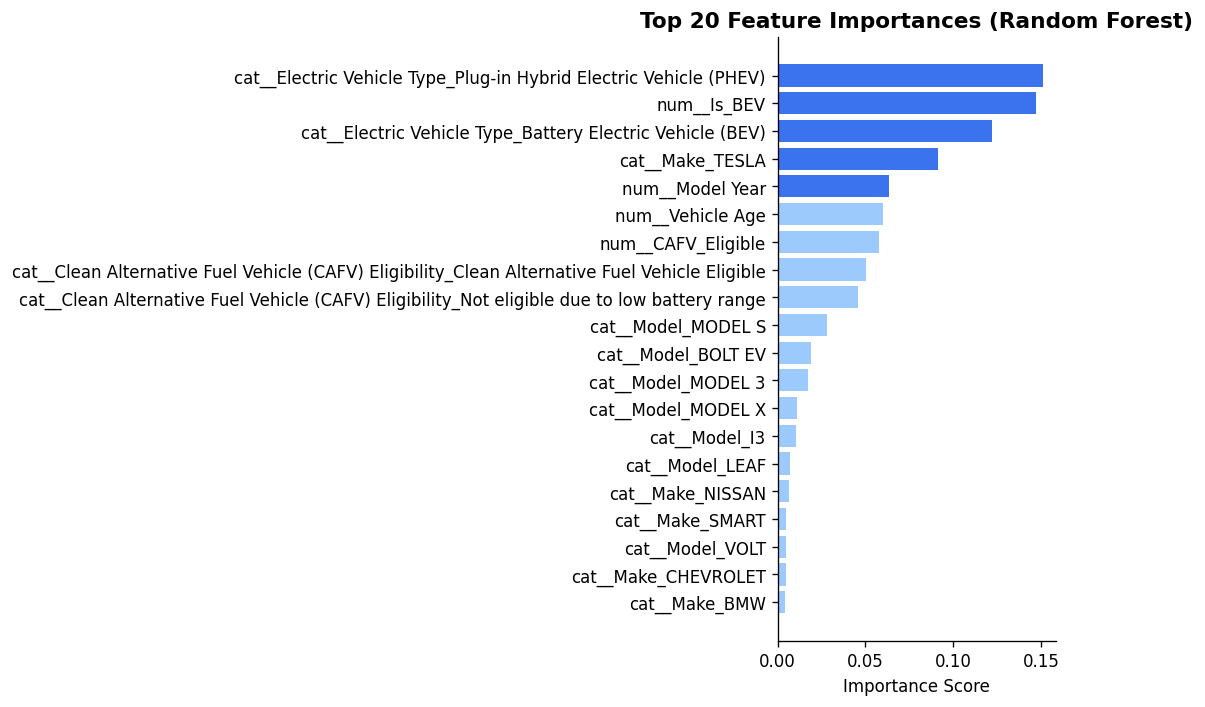

Top 10 features:
                                                                                       Feature  Importance
                             cat__Electric Vehicle Type_Plug-in Hybrid Electric Vehicle (PHEV)    0.150850
                                                                                   num__Is_BEV    0.147184
                                     cat__Electric Vehicle Type_Battery Electric Vehicle (BEV)    0.121791
                                                                               cat__Make_TESLA    0.091472
                                                                               num__Model Year    0.063416
                                                                              num__Vehicle Age    0.059827
                                                                            num__CAFV_Eligible    0.057624
cat__Clean Alternative Fuel Vehicle (CAFV) Eligibility_Clean Alternative Fuel Vehicle Eligible    0.050543
  cat__Clean Alterna

In [17]:
feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()
importances   = pipeline.named_steps["model"].feature_importances_

importance_df = (pd.DataFrame({"Feature": feature_names, "Importance": importances})
                 .sort_values("Importance", ascending=False)
                 .head(20)
                 .reset_index(drop=True))

plt.figure(figsize=(9, 6))
colors = ['#2563eb' if i < 5 else '#93c5fd' for i in range(len(importance_df))]
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1],
         color=colors[::-1], alpha=0.9)
plt.xlabel('Importance Score')
plt.title('Top 20 Feature Importances (Random Forest)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print("Top 10 features:")
print(importance_df[['Feature','Importance']].head(10).to_string(index=False))

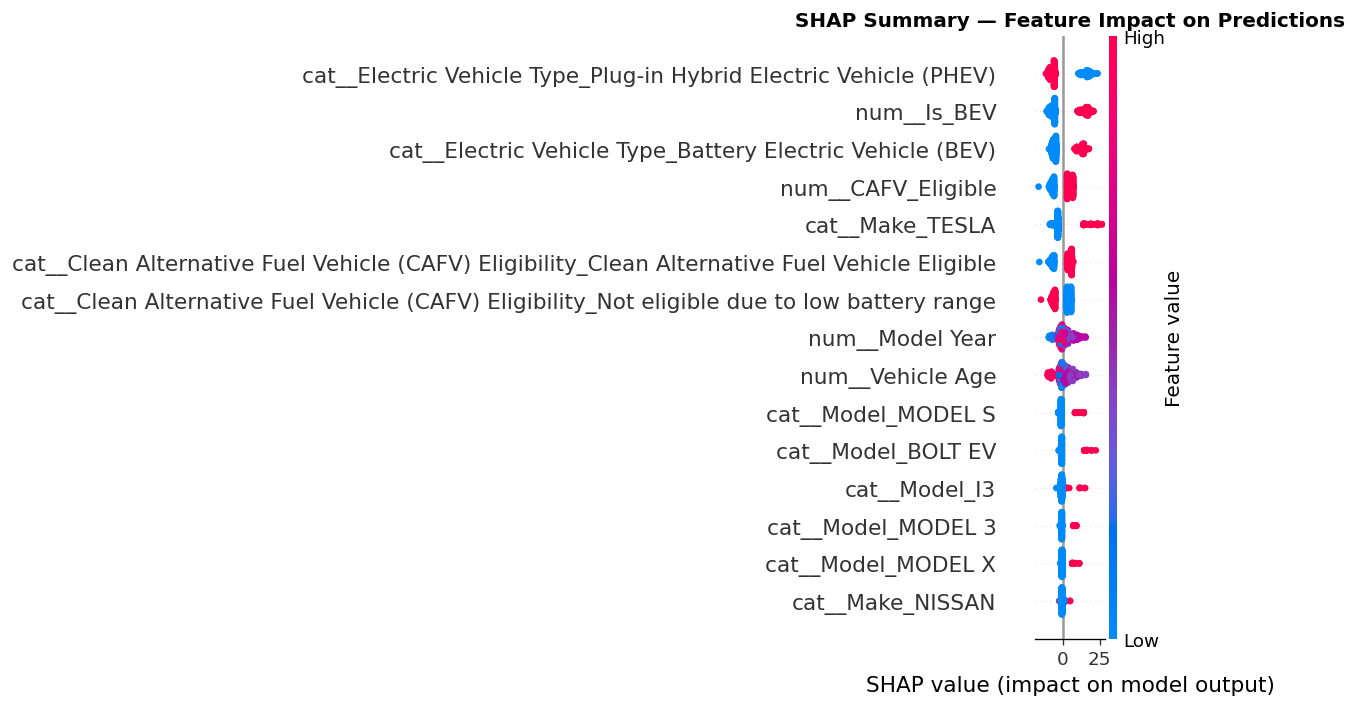

✅ SHAP explainability plot saved


In [18]:
# Transform test data through preprocessor
X_test_transformed = pipeline.named_steps["preprocess"].transform(X_test)

# SHAP explainer on the trained RF model
explainer   = shap.TreeExplainer(pipeline.named_steps["model"])
shap_values = explainer.shap_values(X_test_transformed[:500])  # sample for speed

plt.figure()
shap.summary_plot(
    shap_values,
    X_test_transformed[:500],
    feature_names=feature_names,
    show=False,
    max_display=15,
    plot_size=(10, 6)
)
plt.title("SHAP Summary — Feature Impact on Predictions", fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()
print("✅ SHAP explainability plot saved")

In [19]:
optuna.visualization.plot_optimization_history(study)

In [20]:
optuna.visualization.plot_param_importances(study)

In [21]:
def predict_ev_range(make, model_name, model_year,
                    ev_type="Battery Electric Vehicle (BEV)",
                    cafv="Clean Alternative Fuel Vehicle Eligible",
                    base_msrp=0):
    """
    Predict the electric range of a vehicle.

    Parameters
    ----------
    make        : str   — e.g. 'TESLA', 'NISSAN', 'CHEVROLET'
    model_name  : str   — e.g. 'MODEL 3', 'LEAF', 'BOLT EV'
    model_year  : int   — e.g. 2023
    ev_type     : str   — 'Battery Electric Vehicle (BEV)' or 'Plug-in Hybrid...'
    cafv        : str   — CAFV eligibility string
    base_msrp   : float — base MSRP (use 0 if unknown)

    Returns
    -------
    float — predicted electric range in miles
    """
    vehicle_age = 2025 - model_year
    is_bev      = int("Battery Electric" in ev_type)
    cafv_elig   = int("Clean Alternative" in cafv)

    sample = pd.DataFrame([{
        'Model Year'      : model_year,
        'Make'            : make.upper(),
        'Model'           : model_name.upper(),
        'Electric Vehicle Type': ev_type,
        'Clean Alternative Fuel Vehicle (CAFV) Eligibility': cafv,
        'Base MSRP'       : base_msrp,
        'Vehicle Age'     : vehicle_age,
        'Is_BEV'          : is_bev,
        'CAFV_Eligible'   : cafv_elig
    }])

    pred = pipeline.predict(sample)[0]
    return round(pred, 1)

# ── Example predictions ────────────────────────────────────
examples = [
    ("TESLA",     "MODEL 3",   2023),
    ("TESLA",     "MODEL Y",   2023),
    ("NISSAN",    "LEAF",      2022),
    ("CHEVROLET", "BOLT EV",   2022),
    ("BMW",       "I3",        2020),
    ("RIVIAN",    "R1T",       2023),
]

print(f"{'Make':<12} {'Model':<12} {'Year':<6} {'Predicted Range':>16}")
print("-" * 50)
for make, model_name, year in examples:
    pred = predict_ev_range(make, model_name, year)
    print(f"{make:<12} {model_name:<12} {year:<6} {pred:>14.1f} miles")

Make         Model        Year    Predicted Range
--------------------------------------------------
TESLA        MODEL 3      2023            160.4 miles
TESLA        MODEL Y      2023            158.9 miles
NISSAN       LEAF         2022            148.2 miles
CHEVROLET    BOLT EV      2022            157.2 miles
BMW          I3           2020            153.0 miles
RIVIAN       R1T          2023            144.0 miles


In [22]:
# Save model as pickle
with open("ev_range_model.pkl", "wb") as f:
    pickle.dump(pipeline, f)

# Save feature column list (needed for inference)
with open("ev_range_features.pkl", "wb") as f:
    pickle.dump(list(X_train.columns), f)

print("✅ Model saved  → ev_range_model.pkl")
print("✅ Features saved → ev_range_features.pkl")

# Verify it loads correctly
with open("ev_range_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

test_pred_loaded = loaded_model.predict(X_test[:5])
print(f"\nVerification — first 5 predictions from loaded model:")
print(test_pred_loaded.round(1))

✅ Model saved  → ev_range_model.pkl
✅ Features saved → ev_range_features.pkl

Verification — first 5 predictions from loaded model:
[ 37. 174.  38. 174.  38.]


In [24]:
# Download in Google Colab
try:
    from google.colab import files
    files.download("ev_range_model.pkl")
    files.download("ev_range_features.pkl")
    print("✅ Files downloaded")
except ImportError:
    print("Not in Colab — files saved in current directory.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloaded
